# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from qick import *

from qick.asm_v2 import QickSpan, QickSweep1D

from QickworkspaceV2 import BaseExperiment

soc, soccfg = BaseExperiment.connect_pyro4(
    ns_host="192.168.10.82",
    ns_port=8888,
    proxy_name="myqick",
    data_path=r"D:\Labber_Data\Jay\purcell_tmon\withTWPA",
)

print(soccfg)

QICK library version mismatch: 0.2.381 remote (the board), 0.2.405 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a0fa10b880d442359a82595a954ab5e1@192.168.10.82:44291
[BaseExperiment] Session activated: QICK@192.168.10.82:8888/myqick, data_path='D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA'
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Sun Aug 10 18:48:22 2025):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC p

# Qubit Setting

In [95]:
from QickworkspaceV2.tools.system_tool import ExperimentConfig
from QickworkspaceV2.config.system_cfg import config_list

qubit = "Q3"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

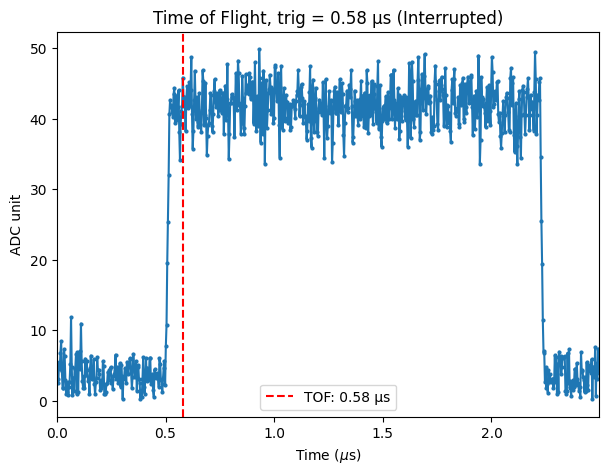

Data saved to D:\Labber_Data\Jay\tmon\2026\08\Data_0805\s001_tof_Q1_20260805T104327498308Z-3DFDASGRT2DCX.hdf5


'D:\\Labber_Data\\Jay\\tmon\\2026\\08\\Data_0805\\s001_tof_Q1_20260805T104327498308Z-3DFDASGRT2DCX.hdf5'

In [104]:
from QickworkspaceV2.experiments.setup import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        "res_sigma": 0.01,
        "res_freq_ge": 4000,
        "ro_length": 2.5,
        "res_length": 1.7,
        "res_gain_ge": 1,
        "res_ch": 0,
        "cheek_e": False,
        "check_f": False,
        "relax_delay": 1,
    }
)

tof = TOF(run_cfg)
tof.run(1000)
tof.saveLabber(qubit)

In [4]:
tof.saveLabber(qubit)


Data saved to D:\Labber_Data\Jay\test\2026\08\Data_0804\s001_tof_Q4_20260804T031650394478Z-D7HJTBTGGDQ4D.hdf5


'D:\\Labber_Data\\Jay\\test\\2026\\08\\Data_0804\\s001_tof_Q4_20260804T031650394478Z-D7HJTBTGGDQ4D.hdf5'

# Instrument Setting

Use `BaseInstrumentManager` to connect Yoko flux sources and RF sources. Fill in your lab addresses before running.

In [3]:
# from QickworkspaceV2.instruments import BaseInstrumentManager

# inst = BaseInstrumentManager()

# # Fill these before running. SGS100A/MG3692 accept either plain IP or full VISA string.
# Q1_FLUX_ADDR = "USB0::0x0B21::0x0039::91S522309::INSTR"
# Q2_FLUX_ADDR = ""  # Optional second Yoko; leave empty to skip
# MG3692_ADDR = "192.168.10.182"

# Q1_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}
# Q2_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}

# q1_flux = inst.add_yoko(
#     "q1_flux",
#     Q1_FLUX_ADDR,
#     limits=Q1_FLUX_LIMITS,
#     current_ramp_step=1e-8,
#     voltage_ramp_step=1e-5,
#     ramp_interval=0.01,
# )

# q2_flux = None
# if Q2_FLUX_ADDR:
#     q2_flux = inst.add_yoko(
#         "q2_flux",
#         Q2_FLUX_ADDR,
#         limits=Q2_FLUX_LIMITS,
#         current_ramp_step=1e-8,
#         voltage_ramp_step=1e-5,
#         ramp_interval=0.01,
#     )

# lo = inst.add_mg3692("pump", MG3692_ADDR)

# inst.status

In [4]:
# inst.set_value("q1_flux", 0.0, mode="current")

## Instrument Quick Checks

Read-only checks plus optional write examples. The write examples are commented out intentionally.

In [6]:
# inst.help()
# inst.limits()
# inst.value("q1_flux")
# inst.ramp("q1_flux")

# Optional Yoko set test. tqdm will show target/current value and remaining time.
# inst.set_value("q1_flux", 0.0, mode="current")

# Optional MG3692 LO setup. Confirm safe frequency/power before uncommenting.
# inst.set(pump", "frequency", 6.0e9)
# inst.set_value("lo", -40)
# inst.off("pump")
# inst.status

# GE State

## Resonator OneTone

Experiment interrupted at 2 averages. Fit is based on partial data.


c:\Users\cluster\Desktop\QickworksaceV2_proj-main\QickworkspaceV2\tools\abcd_rf_fit\abcd_rf_fit.py:261: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


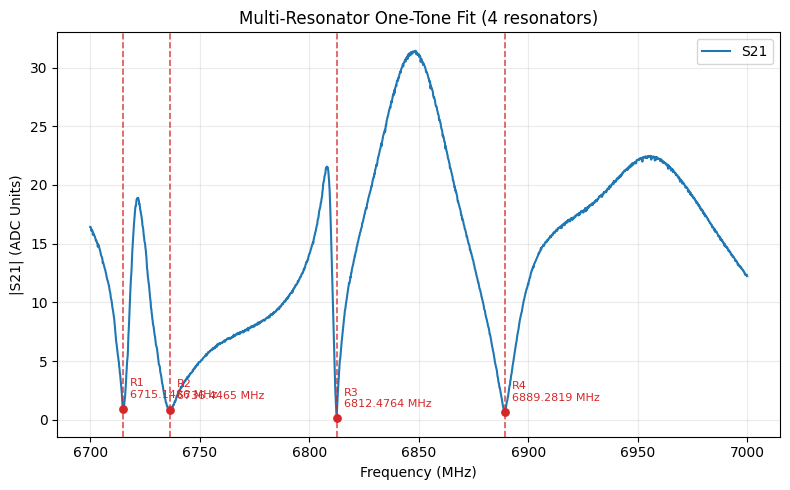

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s002_res_ge_Q1_20260806T074105094079Z-APER4W7MDMJRD.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s002_res_ge_Q1_20260806T074105094079Z-APER4W7MDMJRD.hdf5'

In [82]:
from QickworkspaceV2.experiments.resonator import ResonatorSpec

START_FREQ = 6700  # [MHz]
STOP_FREQ = 7000 #[MHz]



STEPS = 2001
config_all.update('threshold', None)
config_all.update("res_gain_ge", 0.8, q_index=qubit)
config_all.update("res_simga", 0.01)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
onetone.run(py_avg=50, solve_type="hm")
fig, ax, freq = onetone.plot_n_resonators(count=4)
# config_all.update("res_freq_ge",freq)
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

In [95]:
config_all.update('threshold', None)

c:\Users\cluster\Desktop\QickworksaceV2_proj-main\QickworkspaceV2\tools\abcd_rf_fit\abcd_rf_fit.py:261: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)
c:\Users\cluster\Desktop\QickworksaceV2_proj-main\QickworkspaceV2\analysis\resonator.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


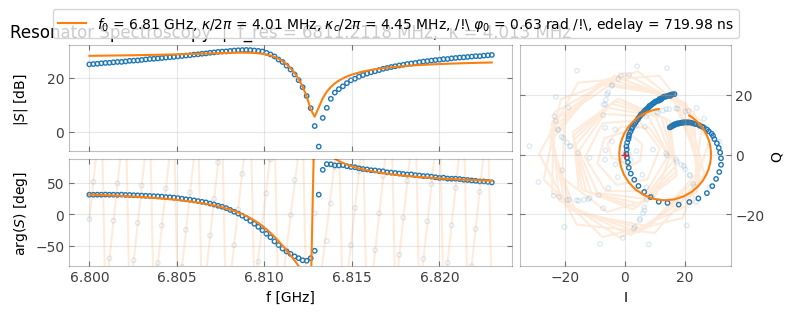

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s002_res_ge_Q3_20260806T122532350710Z-63ZREYBY969MN.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s002_res_ge_Q3_20260806T122532350710Z-63ZREYBY969MN.hdf5'

In [96]:
from QickworkspaceV2.experiments.resonator import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 13  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]

# START_FREQ = 6715-13  # [MHz]
# STOP_FREQ = 6715 + 10  # [MHz]





STEPS = 101
config_all.update('threshold', None)
config_all.update("res_gain_ge", 0.133, q_index=qubit)
config_all.update("res_simga", 0.01)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
onetone.run(py_avg=5, solve_type="hm")
onetone.plot()
## update value ##
config_all.update("res_freq_ge", onetone.result["f_res[MHz]"], q_index=qubit)
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

## Resonator OneTone Flux

Sweep resonator frequency while stepping a Yoko current through `BaseInstrumentManager`. Yoko sweeps now use the manager-registered instrument name.

In [17]:
# from QickworkspaceV2.experiments.resonator import ResonatorSpecFlux

# YOKO_NAME = "q1_flux"
# YOKO_MODE = "current"

# CENTER_FREQ = config_all.get_qubit(qubit)["res_freq_ge"]  # MHz
# FREQ_SPAN = 100  # MHz
# START_FREQ = CENTER_FREQ - FREQ_SPAN / 2
# STOP_FREQ = CENTER_FREQ + FREQ_SPAN / 2
# STEPS = 101

# FLUX_START = -0.5e-3  # A
# FLUX_STOP = 0.5e-3    # A
# FLUX_STEPS = 11
# yoko_values = np.linspace(FLUX_START, FLUX_STOP, FLUX_STEPS)

# config_all.update("res.res_gain_ge", 0.4, q_index=qubit)
# run_cfg = config_all.get_qubit(qubit)
# run_cfg.update(
#     [
#         ("steps", STEPS),
#         ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
#         ("relax_delay", 0),
#         ("yoko_value", yoko_values),
#     ]
# )

# onetone_flux = ResonatorSpecFlux(run_cfg)
# result_flux = onetone_flux.run(
#     py_avg=5,
#     instrument_manager=inst,
#     yoko_name=YOKO_NAME,
#     yoko_value=yoko_values,
#     yoko_mode=YOKO_MODE,
#     show_final_plot=True,
# )

# # onetone_flux.saveLabber(qubit, config_all=config_all)

## OneTone PunchOut

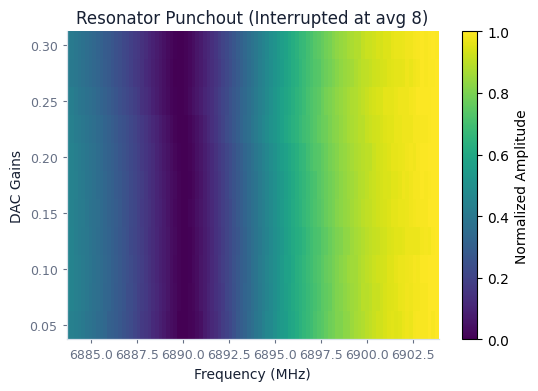

Experiment interrupted at 8 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s002b_res_ge_punchout_Q4_20260806T090443098053Z-DMRZ8PEX03SHD.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s002b_res_ge_punchout_Q4_20260806T090443098053Z-DMRZ8PEX03SHD.hdf5'

In [227]:
from QickworkspaceV2.experiments.resonator import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]

STEPS_freq = 101

START_gain = 0.05
STOP_gain = 0.3
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
        ("relax_delay", 0),
        ('threshold', None)
    ]
)
punchout = Punchout(run_cfg)
punchout.run(py_avg=100, show_final_plot=True)
punchout.saveLabber(qubit, config_all=config_all)

## Dispersive Shift

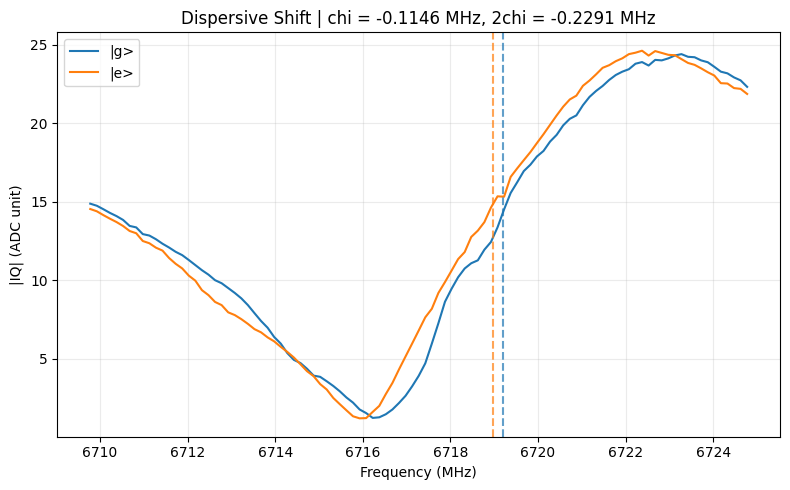

chi = -0.114550 MHz
Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\resonator_chi_ge_Q1_20260806T081448386994Z-B4X4Q2CS9N5WZ.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\resonator_chi_ge_Q1_20260806T081448386994Z-B4X4Q2CS9N5WZ.hdf5'

In [129]:
from QickworkspaceV2.experiments.resonator import Chi

CENTER_FREQ = config_all.get_qubit(qubit)["res_freq_ge"]  # [MHz]
FREQ_SPAN = 15  # [MHz]
STEPS = 101

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", CENTER_FREQ - FREQ_SPAN / 2, CENTER_FREQ + FREQ_SPAN / 2)),
        ("relax_delay", 200),
        ("threshold", None)
    ]
)

chi = Chi(run_cfg)
chi_result = chi.run(py_avg=5, solve_type="hm")
chi.plot()
print(f"chi = {chi_result['chi_MHz']:.6f} MHz")
chi.saveLabber(qubit, config_all=config_all)

## Qubit Spectrum ge

Experiment interrupted at 3 averages. Fit is based on partial data.


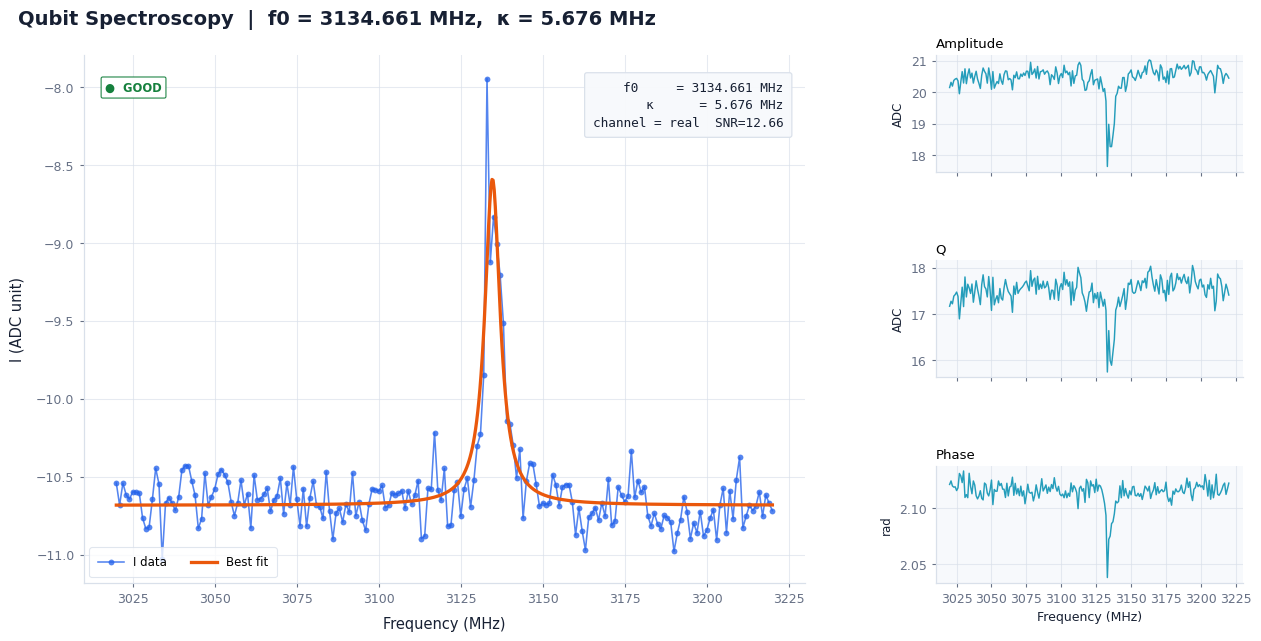

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s003_qubit_spec_ge_Q3_20260806T122544256846Z-DAZRMJFQQV3X0.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s003_qubit_spec_ge_Q3_20260806T122544256846Z-DAZRMJFQQV3X0.hdf5'

In [97]:
from QickworkspaceV2.experiments.qubit_ge import QubitSpec

center = 3120
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

config_all.update("qb_ch", 1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.1),
        ("qb_flat_top_length_ge", 1),
        ("relax_delay", 40),
        ("nqz_qb", 1),
    ]
)

spectrum_ge = QubitSpec(run_cfg)
spectrum_ge.run(50, plot_analysis=True)
f_ge = spectrum_ge.result["f0_MHz"]
config_all.update("qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb_mixer", f_ge, q_index=qubit)
spectrum_ge.saveLabber(qubit, config_all=config_all)

### Fast flux spectrum

In [24]:
# from QickworkspaceV2.experiments.qubit_ge import QubitSpecFlux

# center = 5970
# SPAN = 50
# START_FREQ = center - SPAN  # [MHz]
# STOP_FREQ = center + SPAN  # [MHz]
# STEPS = 201

# START_GAIN = -1
# STOP_GAIN = 1
# STEPS_GAIN = 11

# config_all.update("qb_ch", 2, q_index=qubit)
# run_cfg = config_all.get_qubit(qubit)
# run_cfg.update(
#     [
#         ("steps", STEPS),
#         ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
#         ("qb_mixer", center),
#         ("qb_gain_ge", 0.3),
#         ("qb_flat_top_length_ge", 0.5),
#         ("relax_delay", 1),
#         ("nqz_qb", 2),
#         ("res_length", 3),
#         ("ro_length", 2.478),
#         ("res_gain_ge", 0.95),
#         ("flux_ch", 15),
#         ("flux_gain", QickSweep1D("fluxloop", START_GAIN, STOP_GAIN)),
#         ("steps_flux", STEPS_GAIN),
#         ("flux_length", 0.7),
#     ]
# )

# spectrumff_ge = QubitSpecFlux(run_cfg)
# spectrumff_ge.run(500, swap_xy=True, show_final_plot=True)

## Time Rabi ge

Experiment interrupted at 29 averages. Fit is based on partial data.


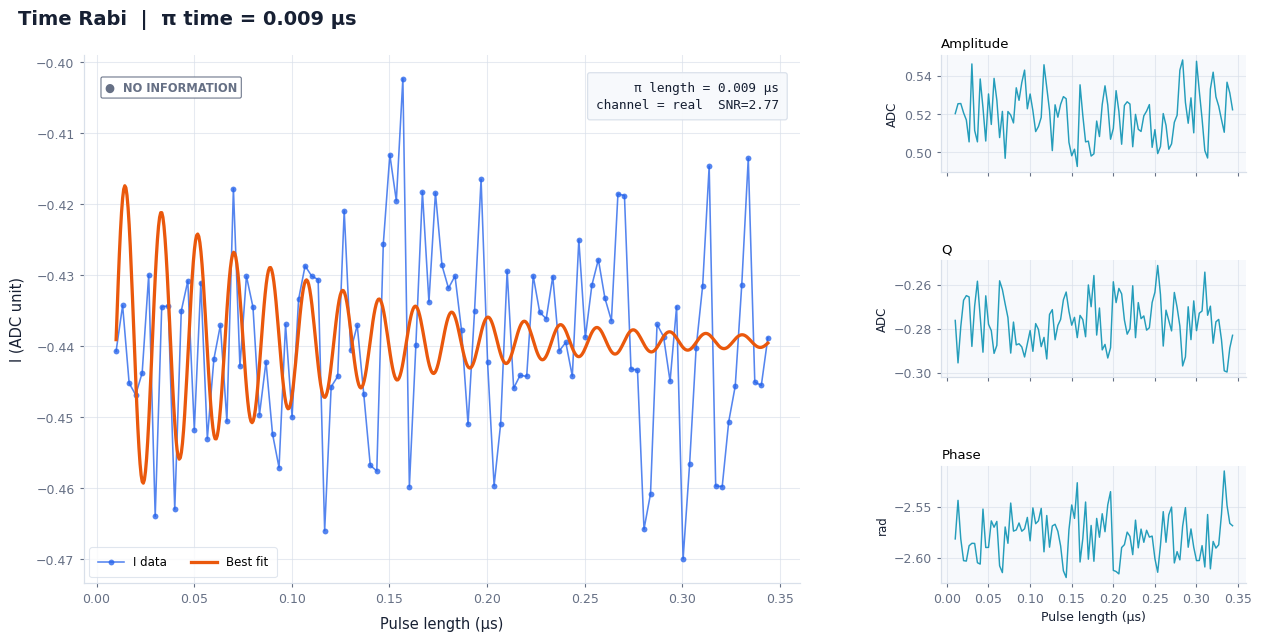

Data saved to D:\Labber_Data\Jay\tmon\2026\08\Data_0806\s004_time_rabi_ge_Q1_20260806T062141445593Z-7FEYBPEMEPB0P.hdf5


'D:\\Labber_Data\\Jay\\tmon\\2026\\08\\Data_0806\\s004_time_rabi_ge_Q1_20260806T062141445593Z-7FEYBPEMEPB0P.hdf5'

In [68]:
from QickworkspaceV2.experiments.qubit_ge import TimeRabi

config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.9),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.5)),
        ("steps", 101),
    ]
)

Trabi = TimeRabi(run_cfg)
Trabi.run(100, plot_analysis=True)
Trabi.saveLabber(qubit, config_all=config_all)

## Power Rabi ge

Experiment interrupted at 2 averages. Fit is based on partial data.


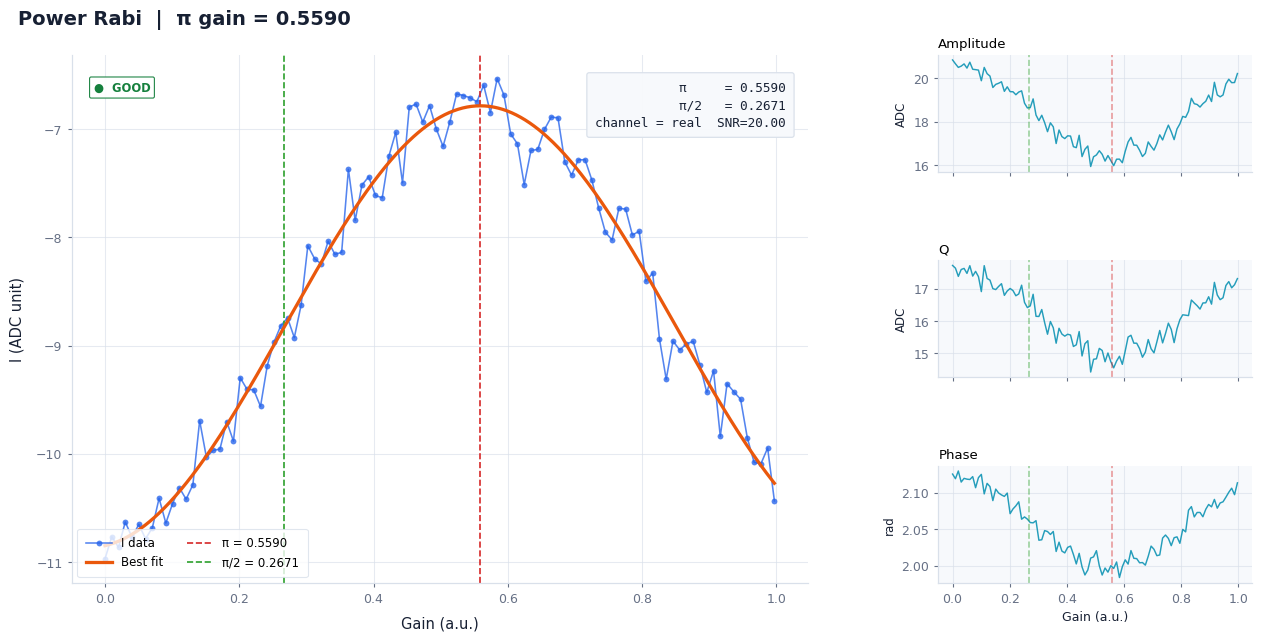

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s005_power_rabi_ge_Q3_20260806T122636613309Z-DPT8TZSYS3T3C.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s005_power_rabi_ge_Q3_20260806T122636613309Z-DPT8TZSYS3T3C.hdf5'

In [104]:
from QickworkspaceV2.experiments.qubit_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ge", 0.02, q_index=qubit)
config_all.update("nqz_qb", 1, q_index=qubit)
config_all.update("relax_delay", 200, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        # ("pulse_type", "drag"),
        # ("qb_flat_top_length_ge", 0.3),
    ]
)

prabi = PowerRabi(run_cfg)
prabi.run(10, plot_analysis=True)
pi_gain, pi2_gain = prabi.result["pi_gain"], prabi.result["pi2_gain"]
config_all.update("pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("pi2_gain_ge", pi2_gain, q_index=qubit)
prabi.saveLabber(qubit, config_all=config_all)

## Active Reset Power Rabi ge

  0%|          | 0/5 [00:00<?, ?it/s]

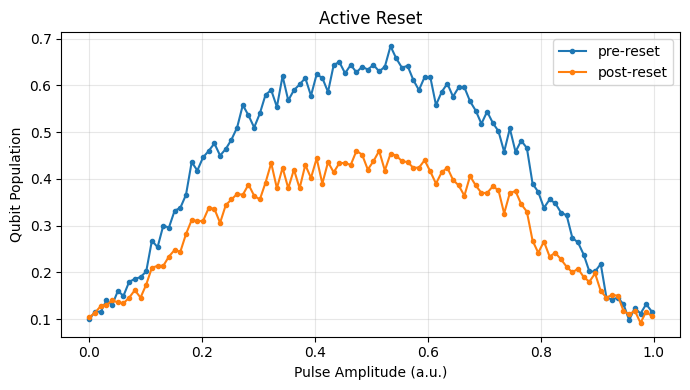

In [71]:
import matplotlib.pyplot as plt
import numpy as np

from QickworkspaceV2.experiments.qubit_ge import ActiveResetRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1.0  # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
THRESHOLD = float(run_cfg["threshold"])  # calibrated normalized I threshold
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        # Current Q1 single-shot has I_e > I_g, so excited shots are >= threshold.
        # Use "<" only after a calibration shows I_e < I_g.
        ("reset_excited_if", ">="),
        ("read_wait", 0.05),  # resync timing validated on current Q1 [us]
        ("feedback_slack", 0.05),  # resync runtime slack [us]
        ("reset_post_delay", 0.05),  # gap after conditional pi pulse [us]
        ("relax_delay", 1.0),
        ("pulse_type", "drag"),
    ]
)

reset_rabi = ActiveResetRabi(run_cfg)
reset_result = reset_rabi.run(5)

# Threshold acquisition returns excited-state population for both readouts.
pre_reset = np.asarray(reset_rabi.pre_reset_population)
post_reset = np.asarray(reset_rabi.post_reset_population)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(reset_result.x_axis, pre_reset, "o-", ms=3, label="pre-reset")
ax.plot(reset_result.x_axis, post_reset, "o-", ms=3, label="post-reset")
ax.set(
    xlabel="Pulse Amplitude (a.u.)",
    ylabel="Qubit Population",
    title="Active Reset",
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

## Amplified Amplitude Error (AAE)


[PowerRabi] Optimal pi gain = 0.290017


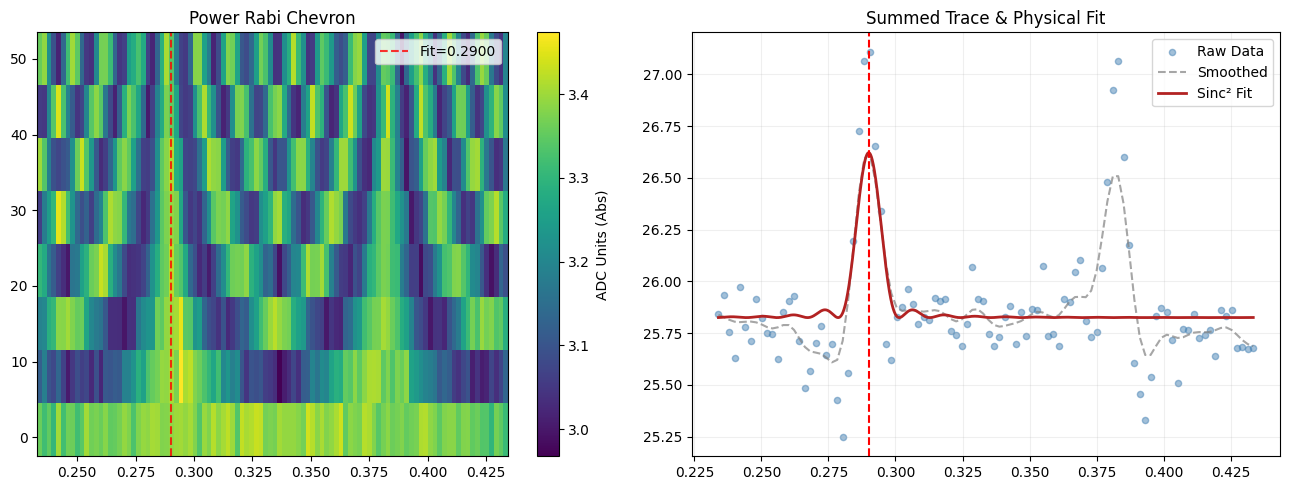

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import PowerRabiChevron

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
focus = run_cfg["pi_gain_ge"]
delta = run_cfg["pi_gain_ge"] - run_cfg["pi2_gain_ge"]
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", focus - delta, focus + delta)),
        # ("pulse_type", "drag"),
        ("iter_start", 1),
        ("iter_stop", 50),
        ("iter_step", 7),
        ('reps', 5)
    ]
)

aae = PowerRabiChevron(run_cfg)
result = aae.run(100)
# config_all.update("pi_gain_ge", result, q_index=qubit)
# config_all.update("pi2_gain_ge", result / 2, q_index=qubit)
# aae.saveLabber(qubit, config_all=config_all)

## Ramsey ge

Experiment interrupted at 1 averages. Fit is based on partial data.


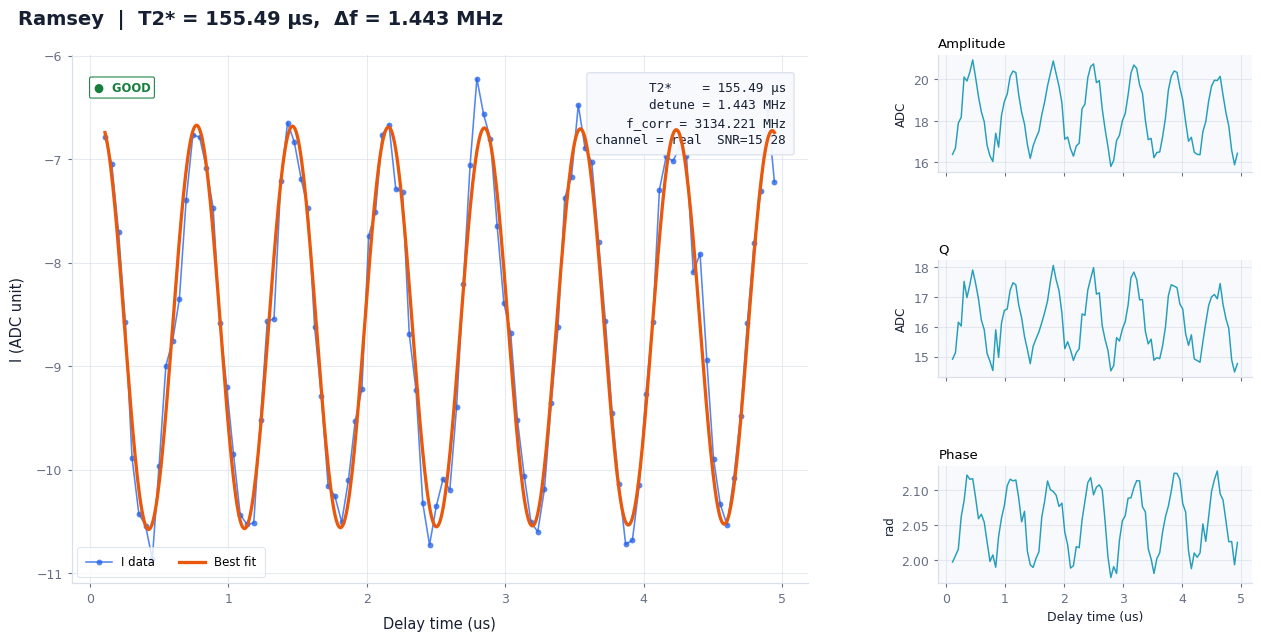

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s006_Ramsey_ge_Q3_20260806T122615604542Z-2G6HKKZH4EC88.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s006_Ramsey_ge_Q3_20260806T122615604542Z-2G6HKKZH4EC88.hdf5'

In [101]:
from QickworkspaceV2.experiments.coherence import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 5  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("virtual_detune", 1),
        # ("pulse_type", "drag"),
    ]
)


t2r = Ramsey(run_cfg)
t2r.run(20, plot_analysis=True)
t2r.saveLabber(qubit, config_all=config_all)

In [102]:
config_all.update("qb_freq_ge", t2r.correct_detune(), qubit)

over detune 0.44334MHz


## Spin Echo

Experiment interrupted at 5 averages. Fit is based on partial data.


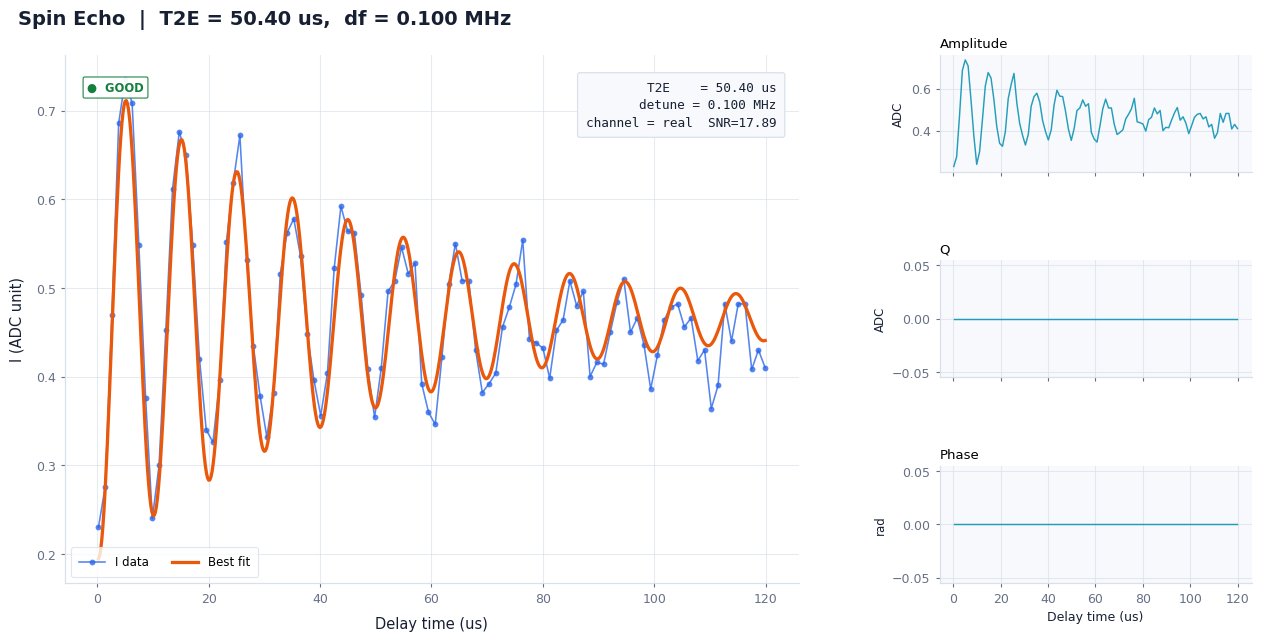

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s007_SpinEcho_ge_Q3_20260806T085313525226Z-FTWQ7EC1K5T6S.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s007_SpinEcho_ge_Q3_20260806T085313525226Z-FTWQ7EC1K5T6S.hdf5'

In [213]:
from QickworkspaceV2.experiments.coherence import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 120  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("virtual_detune", 0.1),
        # ("pulse_type", "drag")
    ]
)

t2e = SpinEcho(run_cfg)
t2e.run(100, plot_analysis=True)
t2e.saveLabber(qubit, config_all=config_all)

## T1 ge

Experiment interrupted at 1 averages. Fit is based on partial data.


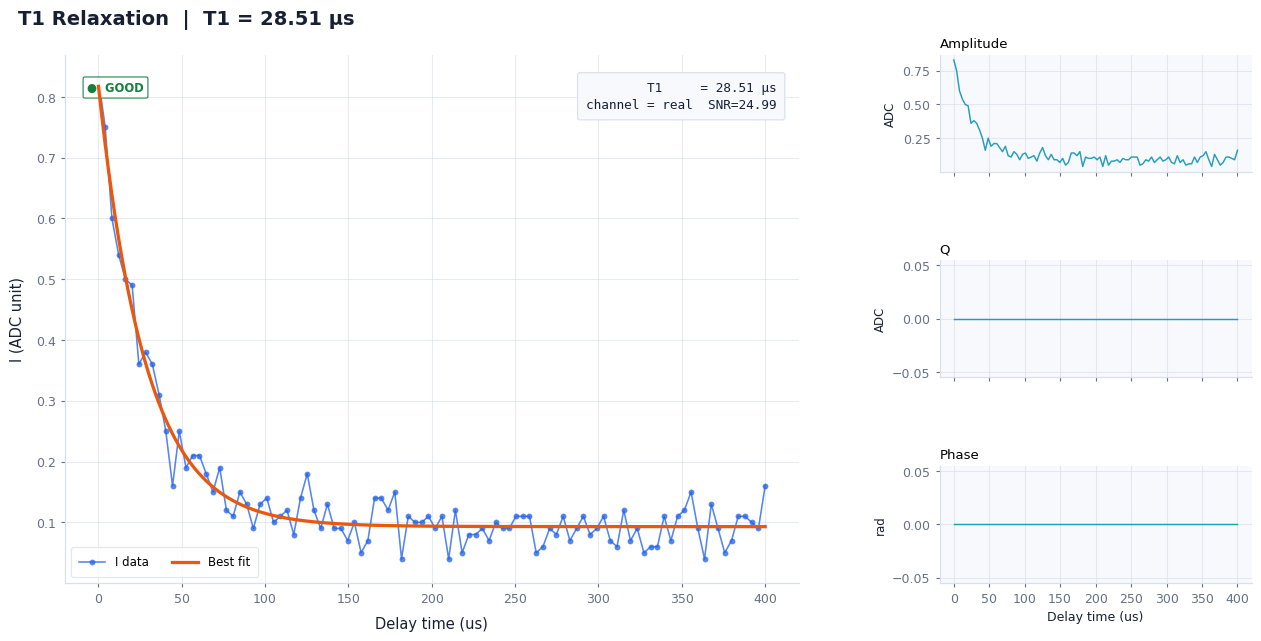

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s008_T1_ge_Q1_20260806T093305333126Z-40BCH4JS3M49V.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s008_T1_ge_Q1_20260806T093305333126Z-40BCH4JS3M49V.hdf5'

In [42]:
from QickworkspaceV2.experiments.coherence import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        # ("pulse_type", "drag"),
    ]
)

t1 = T1(run_cfg)
t1.run(10, plot_analysis=True)
t1.saveLabber(qubit, config_all=config_all)

## Single Shot gef

  0%|          | 0/10000 [00:00<?, ?it/s]

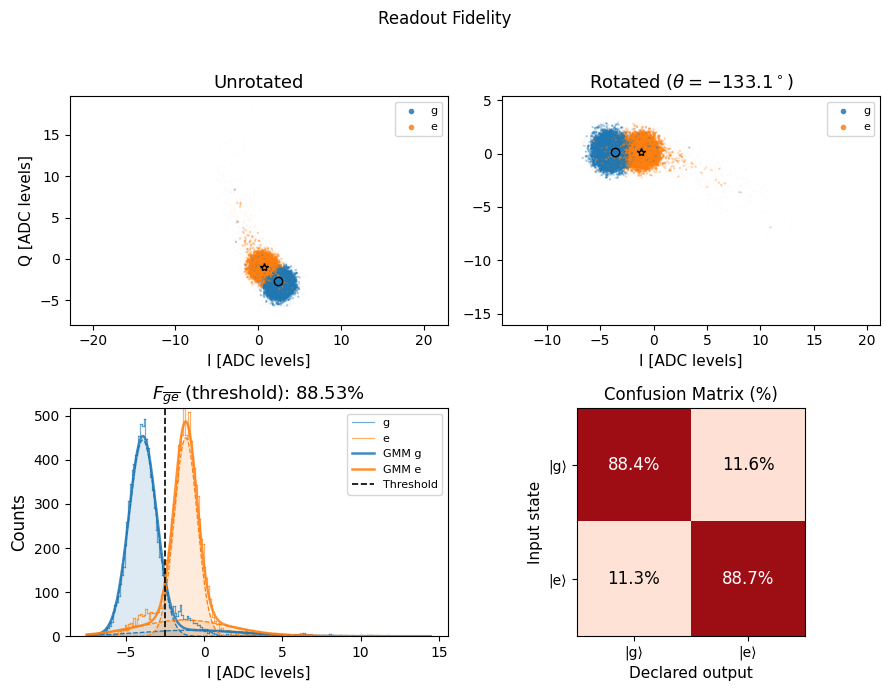

Rotation angle : -133.14 deg
Threshold Fid. : 88.530%
  |g?? components=2  mean=-3.919  std=0.883
  |e?? components=2  mean=-1.173  std=0.733
Thresholds     : ['-2.475']
Confusion Matrix (%):
 [[88.4 11.6]
 [11.3 88.7]]
Current data file: D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s000_singleshot_ge_Q3_001


In [106]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

### run single shot with optimized parameters ###
config_all.update("res_simga", 0.005)
config_all.update("res_phase", 0, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

# run_cfg['pulse_type'] = "drag"
SHOT = 10000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update("res_phase", ssh_result[2], q_index=qubit)
ssh.saveLabber(qubit)

THRESHOLD=True
if THRESHOLD:
    config_all.update('threshold', ssh_result[1][0], q_index=qubit)

### ssh opt

Length loop:   0%|          | 0/11 [00:00<?, ?it/s]

Analyze [threshold fidelity (ge)]:   0%|          | 0/11 [00:00<?, ?it/s]


0/11 grid points pass physical constraints.

--- Grid best (T1-weighted, feasible) ---
  score=0.9072  fid=0.9012  e->g=0.0919  g->e=0.1057  T1_weight=15.00
  length=5.0  gain=0.133  freq=6812.8742


  0%|          | 0/10000 [00:00<?, ?it/s]

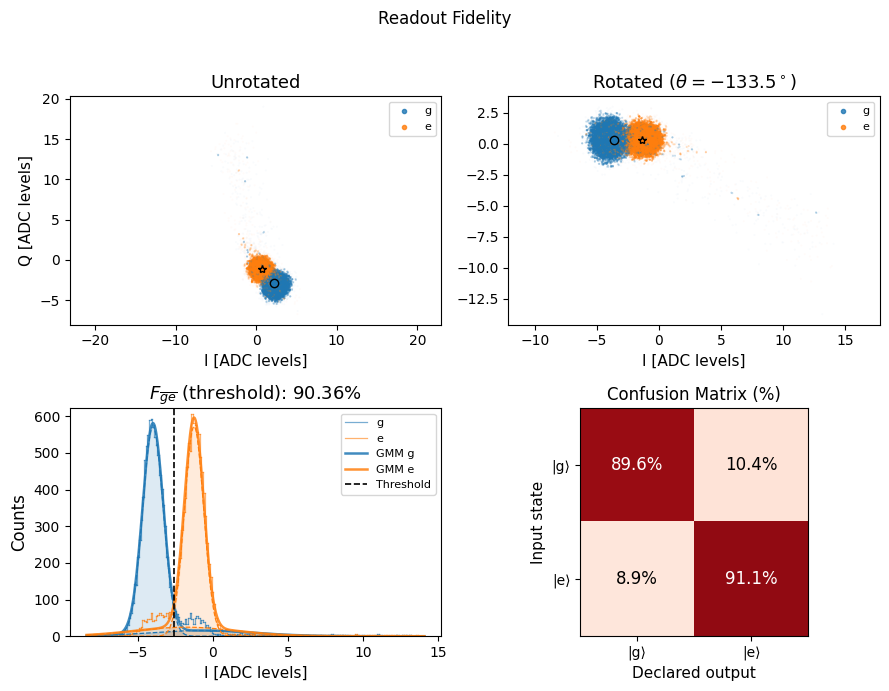

Rotation angle : -133.53 deg
Threshold Fid. : 90.355%
  |g?? components=2  mean=-3.984  std=0.691
  |e?? components=2  mean=-1.245  std=0.641
Thresholds     : ['-2.594']
Confusion Matrix (%):
 [[89.6 10.4]
 [ 8.9 91.1]]


In [108]:
from QickworkspaceV2.experiments.setup import SingleShot_ge_opt
from QickworkspaceV2.experiments.setup import SingleShot_gef
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 5, run_cfg["res_freq_ge"] + 5, 11)
gain_axis = np.linspace(0.1, 0.2, 7)
length_axis = np.linspace(0.5, 5.0, 11)
sweep_para = {"freq":run_cfg["res_freq_ge"], "gain":run_cfg["res_gain_ge"], "length":length_axis}

SHOT = 3000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze(pareto=True, t1_decay_weight=15.0)

config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
config_all.update("res_phase", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

SHOT = 10000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)

# Threshold and phase belong to this exact optimized readout point.
config_all.update("res_phase", ssh_result[2], q_index=qubit)
config_all.update("threshold", ssh_result[1][0], q_index=qubit)


=== Top 5 points (feasible first, then by fidelity) ===
         L         G         F     fid    soft     snr    leak   therm   ok?
         5     0.133      6813  0.9012  0.8307   1.606  0.092  0.106   yes
       4.1     0.133      6813  0.8879  0.8145   1.276  0.101  0.124   yes
      4.55     0.133      6813  0.8897  0.8189   1.036  0.103  0.117   yes
      3.65     0.133      6813  0.8755  0.7988   1.166  0.115  0.134   yes
       3.2     0.133      6813  0.8672  0.8045   0.706  0.121  0.144   yes

=== Diagnostics for best point ===
  [ok] |e> -> |g> error OK (0.092)
  [!] High |g> -> |e> error (0.106) - this is an assignment error; ge-only data alone does not determine thermal population.
  [ok] Hard and soft fidelities agree (delta = -0.0705).

=== Full hist for best point: L=5, G=0.133, F=6813  (fid=0.9012, soft=0.8307) ===


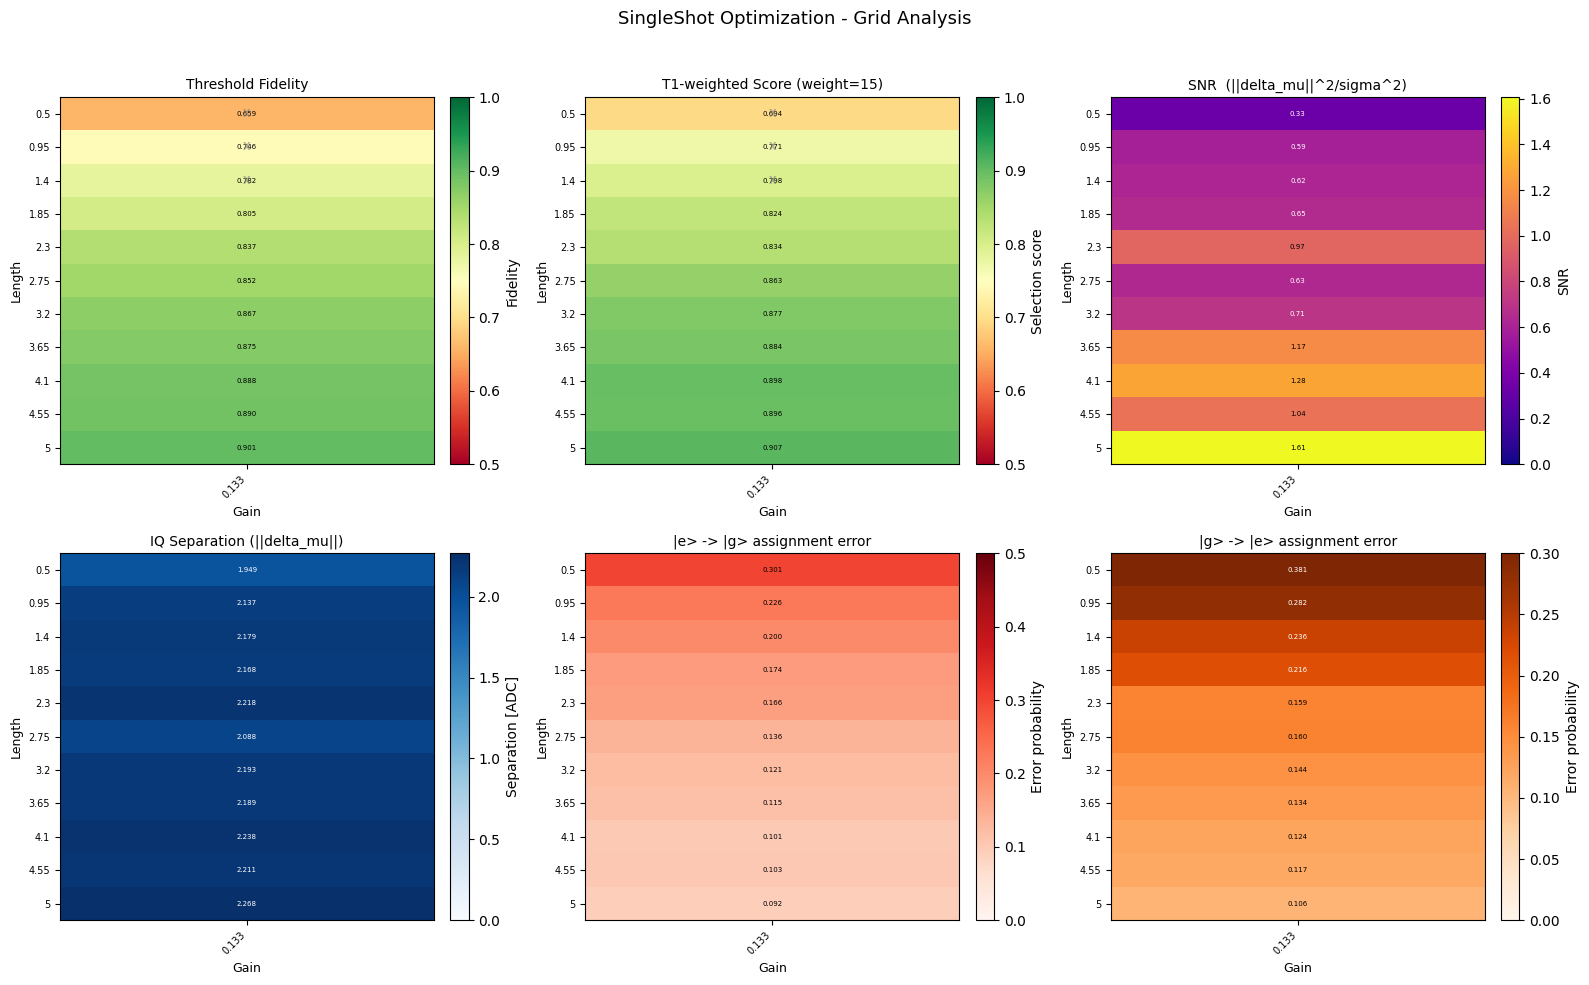

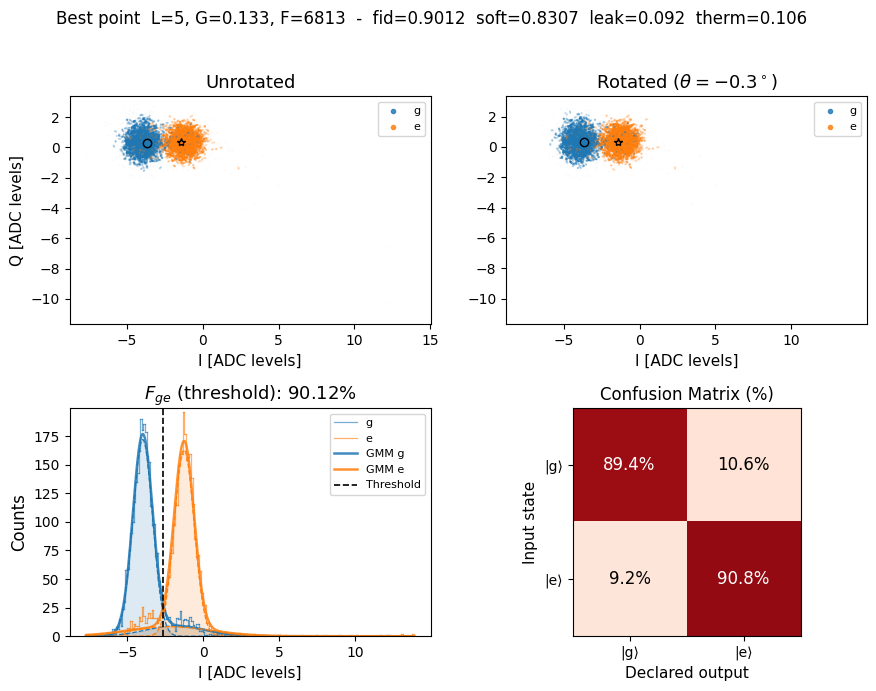

Rotation angle : -0.32 deg
Threshold Fid. : 90.121%
  |g?? components=2  mean=-3.979  std=0.649
  |e?? components=2  mean=-1.250  std=0.655
Thresholds     : ['-2.614']
Confusion Matrix (%):
 [[89.4 10.6]
 [ 9.2 90.8]]


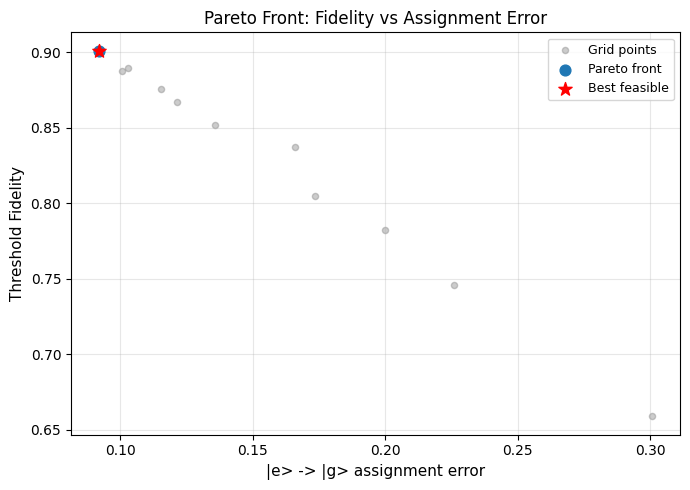


Plotting top 8 fidelity points (feasible only)...


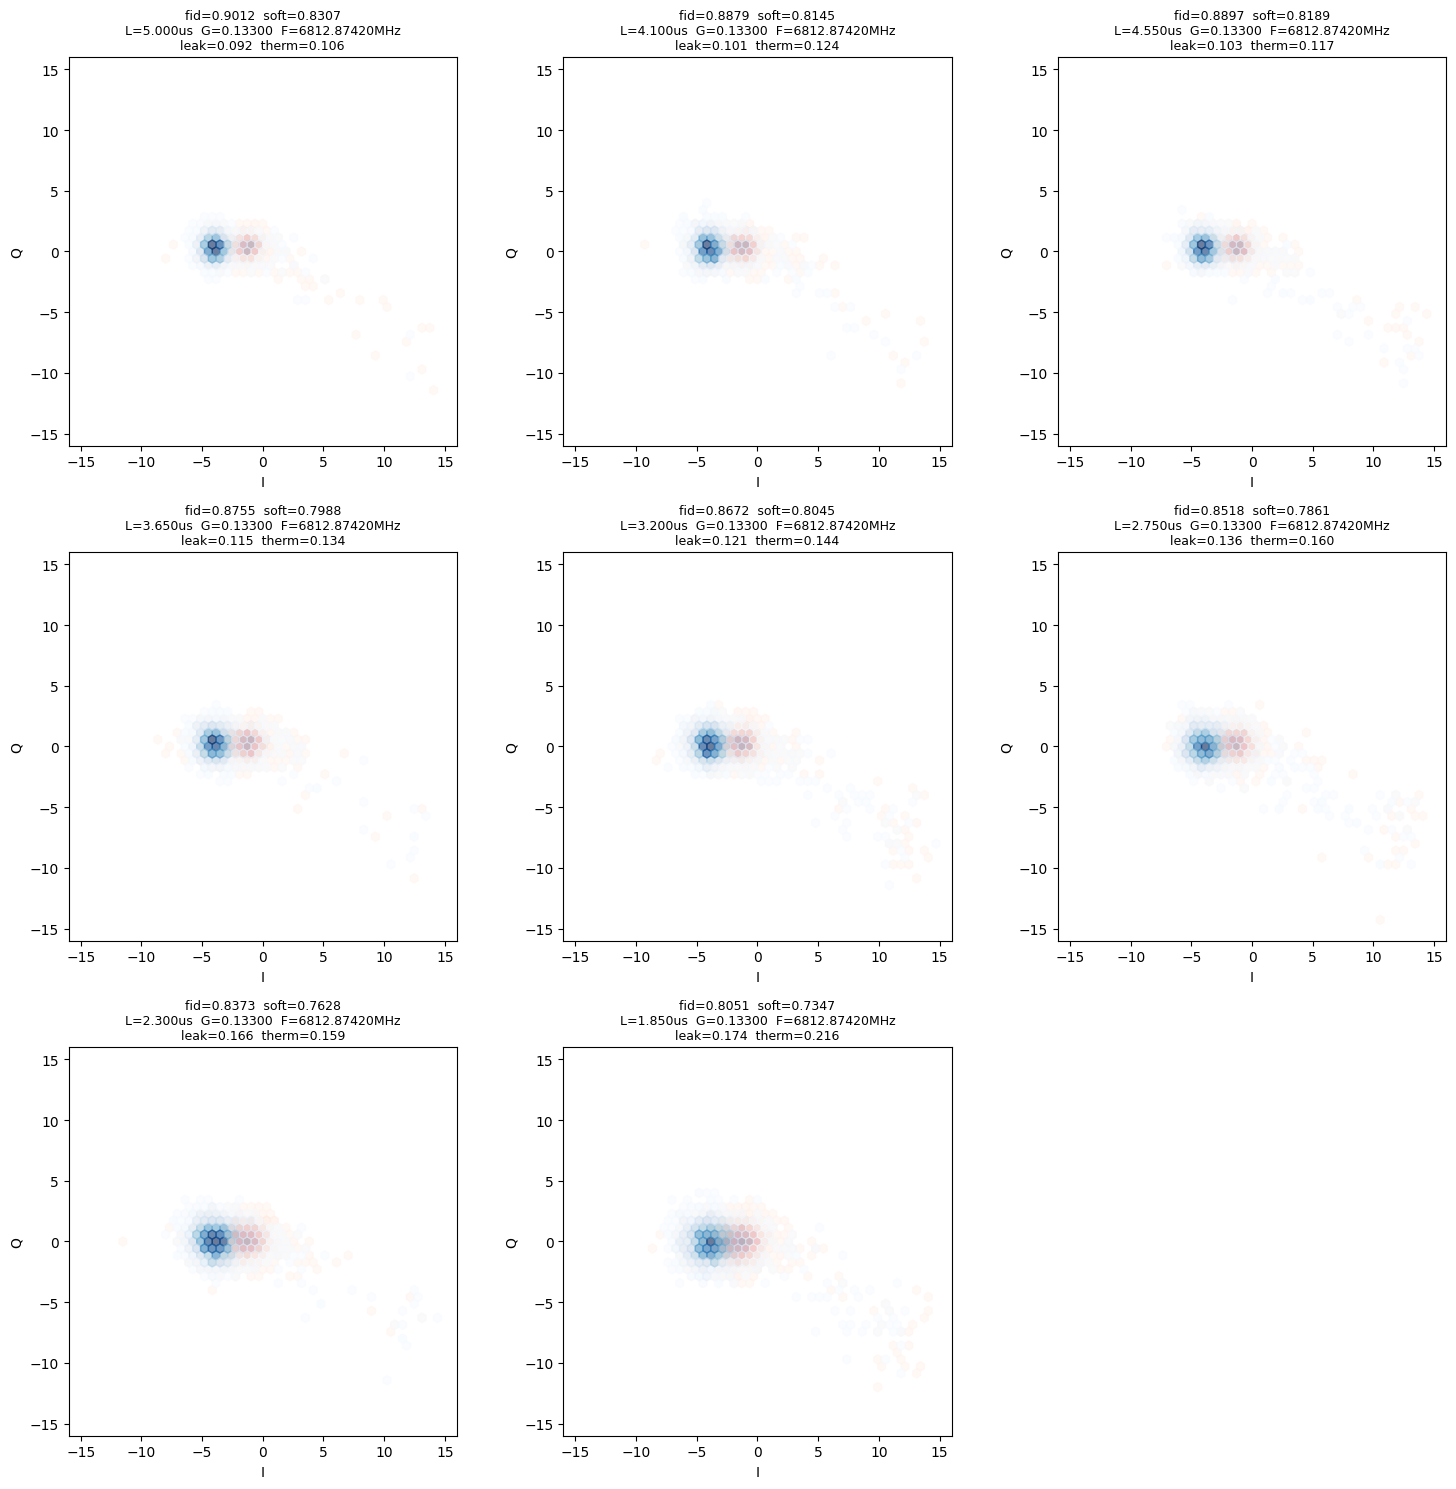

In [109]:
ssh_opt.plot_grid_analysis()
ssh_opt.plot_pareto()
ssh_opt.plot_top_fidelity_histograms(top_n=9)

# EF State

## Resonator OneTone ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
    ]
)

onetone_ef = ResonatorSpec_ef(run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", fres["f_res[MHz]"], q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 3 averages. Fit is based on partial data.


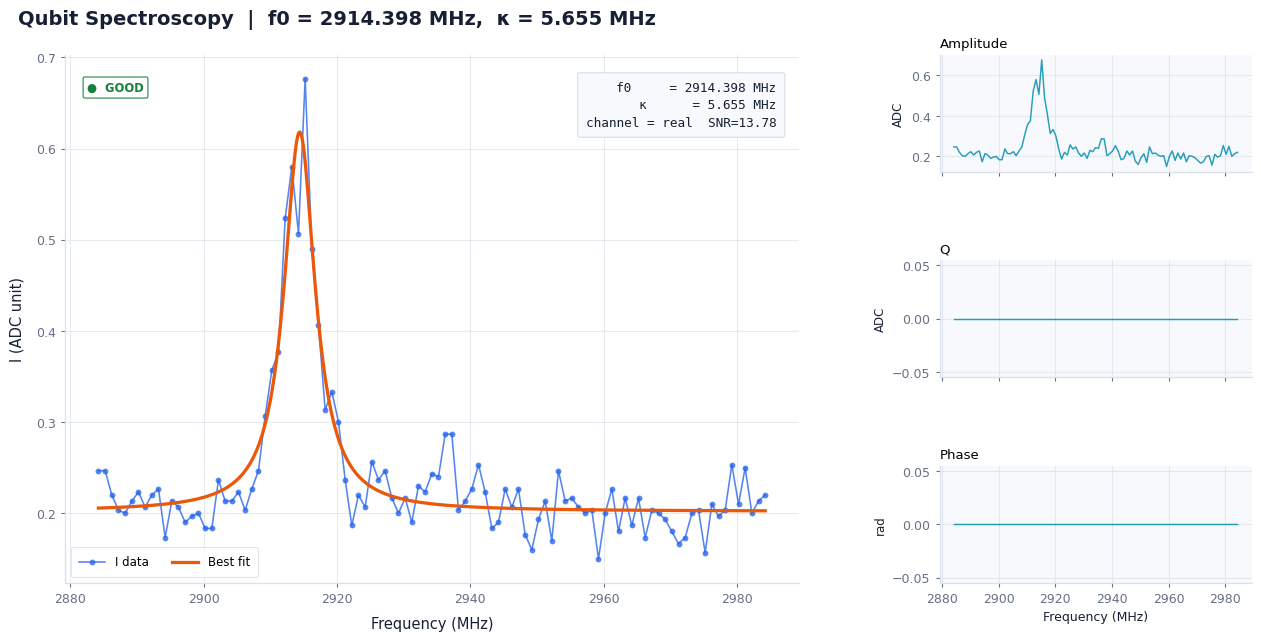

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s010_qubit_spec_ef_Q3_20260806T084640761605Z-CKPWMTQ4EBXHH.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s010_qubit_spec_ef_Q3_20260806T084640761605Z-CKPWMTQ4EBXHH.hdf5'

In [198]:
from QickworkspaceV2.experiments.qubit_ef import QubitSpecEf

center = config_all.get_qubit(qubit)["qb_freq_ge"] - 200
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 101

config_all.update("qb_ch_ef", 1, q_index=qubit)
config_all.update("nqz_qb_ef", 1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.3),
        ("qb_flat_top_length_ef", 2),
        ("ge_ref", True),
    ]
)

spectrum_ef = QubitSpecEf(run_cfg)
result_ef = spectrum_ef.run(10, plot_analysis=True)
f_ef = result_ef.scalar_result
config_all.update("qb_freq_ef", f_ef, q_index=qubit)
# config_all.update("qb_mixer_ef", f_ge, q_index=qubit)
spectrum_ef.saveLabber(qubit, config_all=config_all)

## Power Rabi ef

Experiment interrupted at 5 averages. Fit is based on partial data.


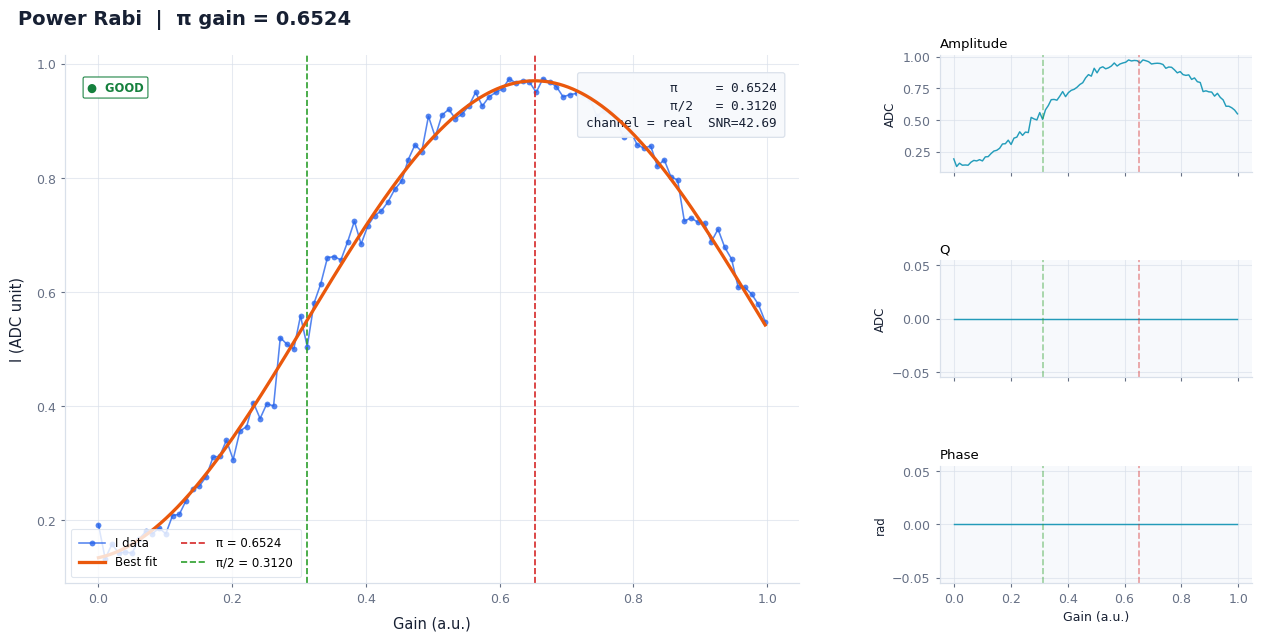

Data saved to D:\Labber_Data\Jay\test\2026\08\Data_0805\s011_power_rabi_ef_Q1_20260805T073247311648Z-DNTYK6EY6WQWS.hdf5


'D:\\Labber_Data\\Jay\\test\\2026\\08\\Data_0805\\s011_power_rabi_ef_Q1_20260805T073247311648Z-DNTYK6EY6WQWS.hdf5'

In [81]:
from QickworkspaceV2.experiments.qubit_ef import PowerRabiEf

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
    ]
)

prabi_ef = PowerRabiEf(run_cfg)
result_ef = prabi_ef.run(50, plot_analysis=True)
pi_gain_ef = result_ef["pi_gain"]
pi2_gain_ef = result_ef["pi2_gain"]
config_all.update("pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

## Qubit Temperature ef

[Temp] A_meas=0.0702  A_ref=0.6668  ratio=0.1053
[Temp] Estimated temperature: 77.41 mK
[Temp] Temperature error: +/- 7.39 mK
[Temp] 1-sigma temperature floor: 45.90 mK


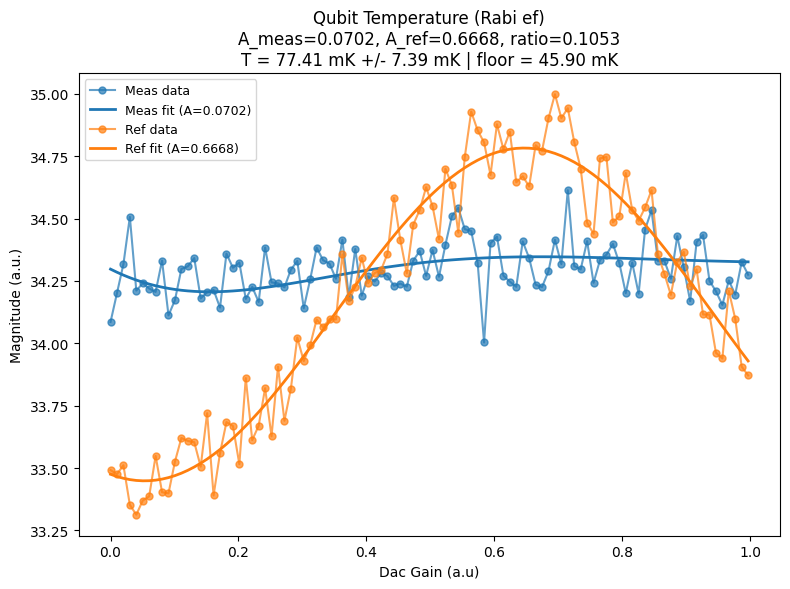

Data saved to D:\Labber_Data\Jay\test\2026\08\Data_0805\s013b_qubit_temp_ef_Q1_001


In [107]:
from QickworkspaceV2.experiments.qubit_ef import QubitTemp

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),

    ]
)

rabi_temp = QubitTemp(run_cfg)
rabi_temp.run(5, plot_analysis=True)
rabi_temp.saveLabber(qubit, config_all=config_all)

## Ramsey ef

Experiment interrupted at 2 averages. Fit is based on partial data.


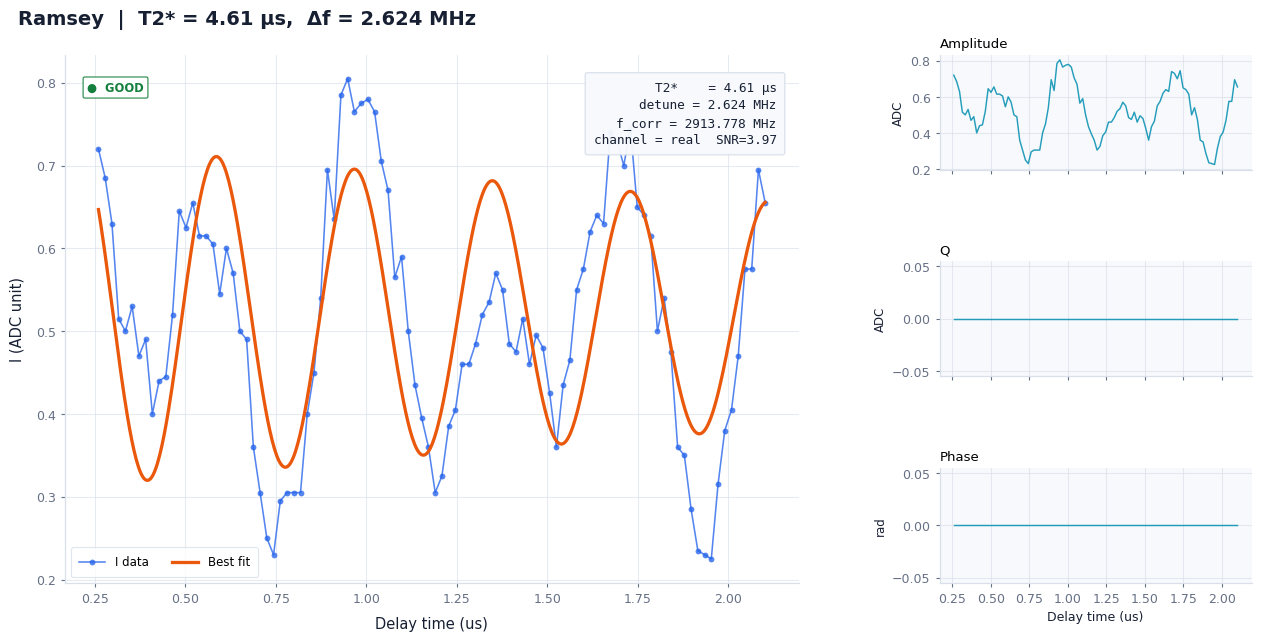

ExperimentData(type='s012_Ramsey_ef', id='20260806T084740452398Z-EW145QXYGEZG1', quality=good, status=interrupted)

In [200]:
from QickworkspaceV2.experiments.qubit_ef import RamseyEf

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("virtual_detune", 2),
        ("ge_ref", True),
    ]
)

t2r_ef = RamseyEf(run_cfg)
t2r_ef.run(100, plot_analysis=True)
# t2r_ef.saveLabber(qubit, config_all=config_all)

In [201]:
config_all.update("qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune 0.62381MHz


## T1 ef

Experiment interrupted at 13 averages. Fit is based on partial data.


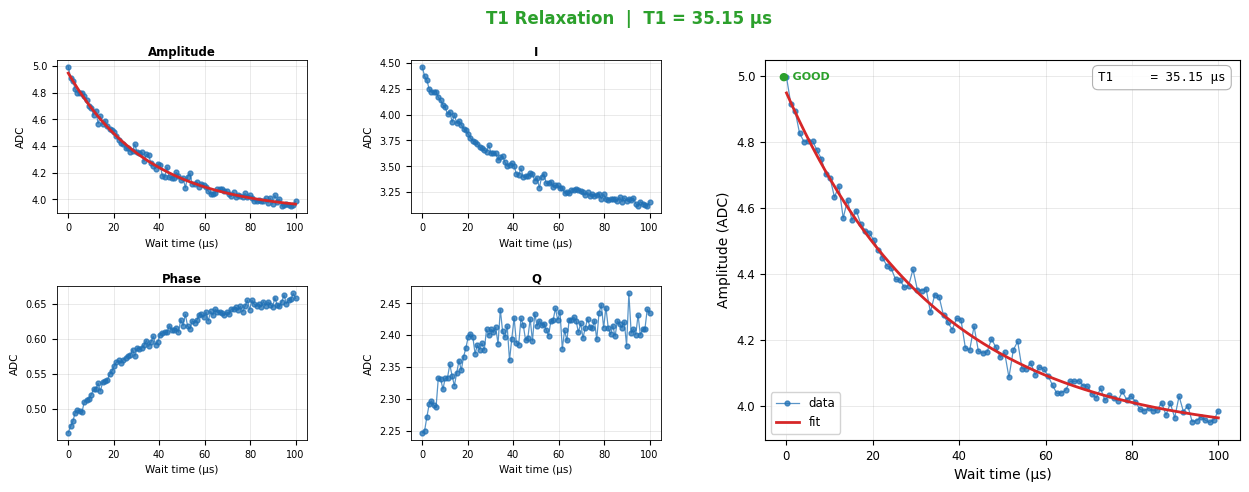

ExperimentData(type='s013_T1_ef', id='eee74ad5', quality=good, status=interrupted)

In [37]:
from QickworkspaceV2.experiments.qubit_ef import T1Ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 100  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
    ]
)

t1_ef = T1Ef(run_cfg)
t1_ef.run(50)
# t1_ef.saveLabber(qubit, config_all=config_all)

## Single Shot gef (ef)

In [14]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = 'drag'

SHOT = 20000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)
ssh.saveLabber(qubit, config_all=config_all)

  0%|          | 0/20000 [00:00<?, ?it/s]

KeyboardInterrupt: 

### ssh opt (ef)

Length loop:   0%|          | 0/6 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

...

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Analyze [threshold fidelity (gef)]:   0%|          | 0/6 [00:00<?, ?it/s]


5/120 grid points pass physical constraints.

--- Grid best (feasible) ---
  fid=0.7440  length=3.2  gain=0.3  freq=6716.3175


  0%|          | 0/5000 [00:00<?, ?it/s]

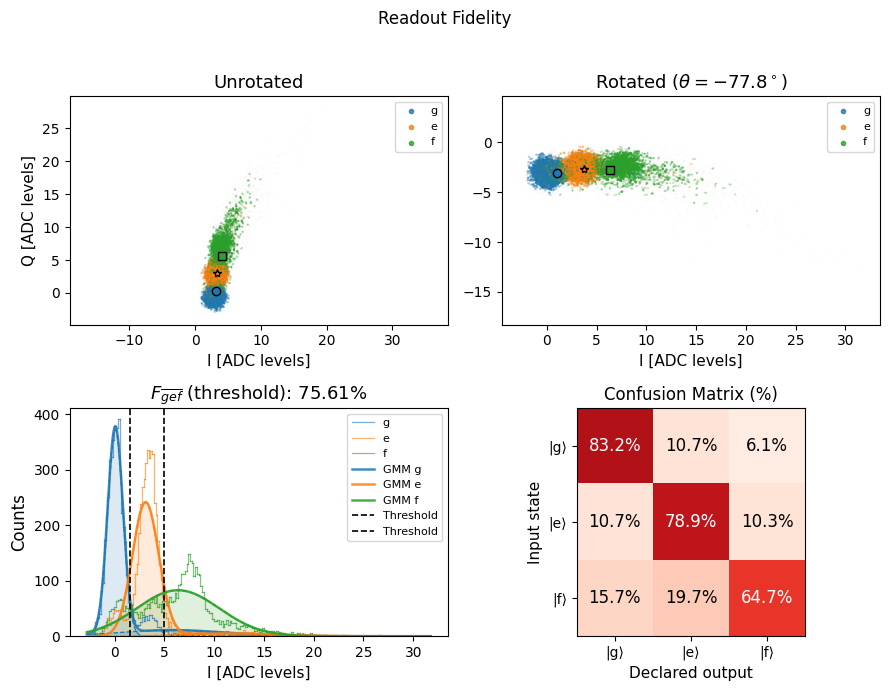

Rotation angle : -77.77 deg
Threshold Fid. : 75.613%
  |g?? components=2  mean=0.064  std=0.769
  |e?? components=2  mean=3.106  std=1.326
  |f?? components=1  mean=6.359  std=4.151
Thresholds     : ['1.581', '4.948']
Confusion Matrix (%):
 [[83.2 10.7  6.1]
 [10.7 78.9 10.3]
 [15.7 19.7 64.7]]


[[0.7561333333333332],
 [1.580779086392028, 4.948267701581317],
 -77.77027027027027,
 array([[83.22, 10.72,  6.06],
        [10.74, 78.94, 10.32],
        [15.66, 19.66, 64.68]])]

In [92]:
from QickworkspaceV2.experiments.setup import SingleShot_ge_opt

USE_DRAG = False

run_cfg = config_all.get_qubit(qubit)
if USE_DRAG:
    run_cfg["pulse_type"] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 1, run_cfg["res_freq_ge"] + 5, 4)
gain_axis = np.linspace(0.1, 0.3, 5)
length_axis = np.linspace(0.5, 5, 6)
sweep_para = {"freq": freq_axis, "gain": gain_axis, "length": length_axis}

SHOT = 10000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para, shot_f=True)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze(t1_decay_weight=3.0)
config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
config_all.update("res_phase", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

if USE_DRAG:
    run_cfg["pulse_type"] = "drag"

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)

# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

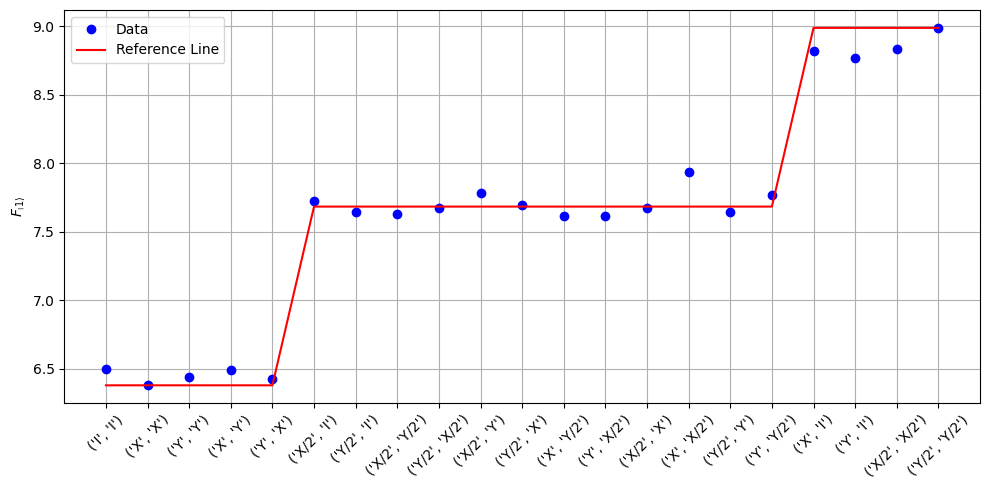

In [137]:
from QickworkspaceV2.experiments.characterization import AllXY

run_cfg = config_all.get_qubit(qubit)

allxy = AllXY(run_cfg)
allxy.run(10)
allxy.plot()

### Drag AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

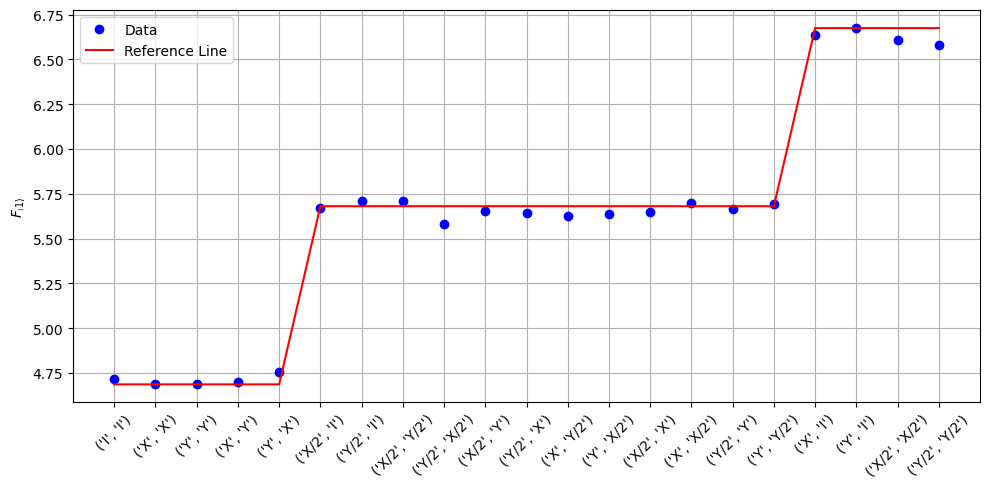

In [43]:
from QickworkspaceV2.experiments.characterization import AllXY

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("pulse_type", "drag"),
    ]
)
allxy = AllXY(run_cfg)
allxy.run(10)
allxy.plot()

## State Tomography

Calibrating |0⟩ state...
Calibrating |1⟩ state...
IQ Ground: (4.972558177379984-1.1562392188771358j), IQ Excited: (7.062102522375916-1.2602766476810414j)


Tomography (x90):   0%|          | 0/3 [00:00<?, ?it/s]


<X>=-0.1765, <Y>=-1.0000, <Z>=0.0867
Purity: 1.00000


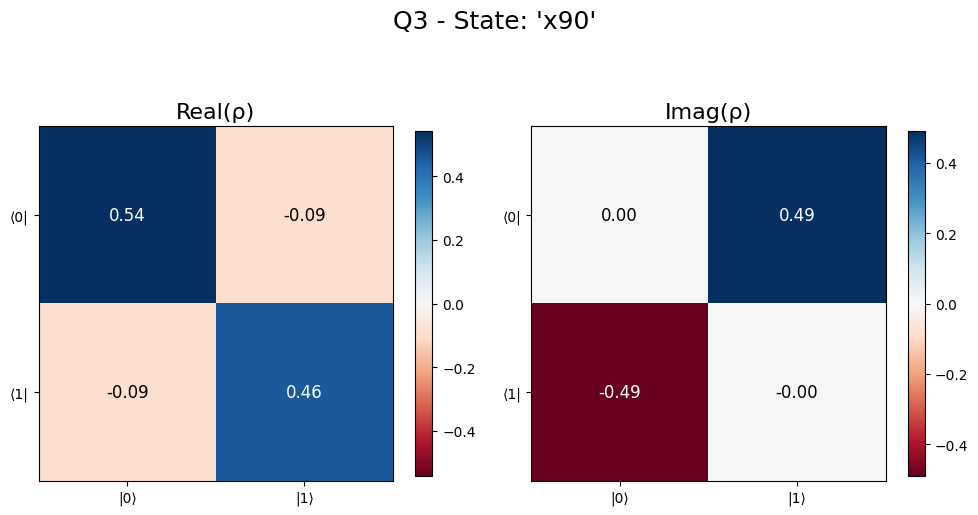

c:\Users\cluster\Desktop\QickworksaceV2_proj-main\QickworkspaceV2\experiments\characterization\state_tomography.py:352: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


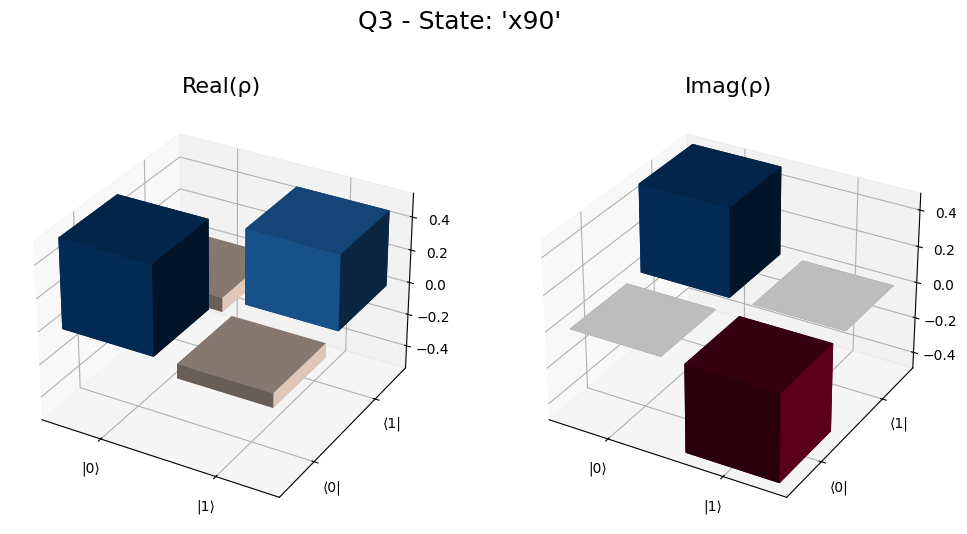

(<Figure size 1200x600 with 2 Axes>, None)

In [177]:
from QickworkspaceV2.experiments.characterization import Tomography

pyavg = 5

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"
tomo = Tomography(run_cfg)
tomo.run(py_avg=pyavg, prep_pulse_name="x90")
tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking

AutoRB:   0%|          | 0/2 [00:00<?, ?it/s]

[RB] QICK threshold=5.609055240147173; reporting ground survival P(g)=1-P(I>threshold).


Compile Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

Software Average:   0%|          | 0/1 [00:00<?, ?it/s]

Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/4 [00:00<?, ?it/s]

Samples:   0%|          | 0/4 [00:00<?, ?it/s]

Samples:   0%|          | 0/4 [00:00<?, ?it/s]

Samples:   0%|          | 0/4 [00:00<?, ?it/s]

[fitrb] p=0.989744  a=0.3927  b=0.5236
[fitrb] σ(p)=6.92e-04  σ(a)=1.12e-02  σ(b)=5.68e-03
[fitrb] p=0.993307  a=0.3830  b=0.5266
[fitrb] σ(p)=5.34e-04  σ(a)=1.14e-02  σ(b)=8.70e-03

--- Reference RB ---
  p   = 99.330668 ± 0.053443 %
  EPC = 0.334666 ± 0.026721 %
[fitrb] p=0.989744  a=0.3927  b=0.5236
[fitrb] σ(p)=6.92e-04  σ(a)=1.12e-02  σ(b)=5.68e-03

--- IRB (X/2) ---
  p   = 98.974357 ± 0.069217 %
  EPC = 0.512822 ± 0.034608 %
  Gate 'X/2': F = 99.8206%, EPC = 0.1794 ± 0.0440 %


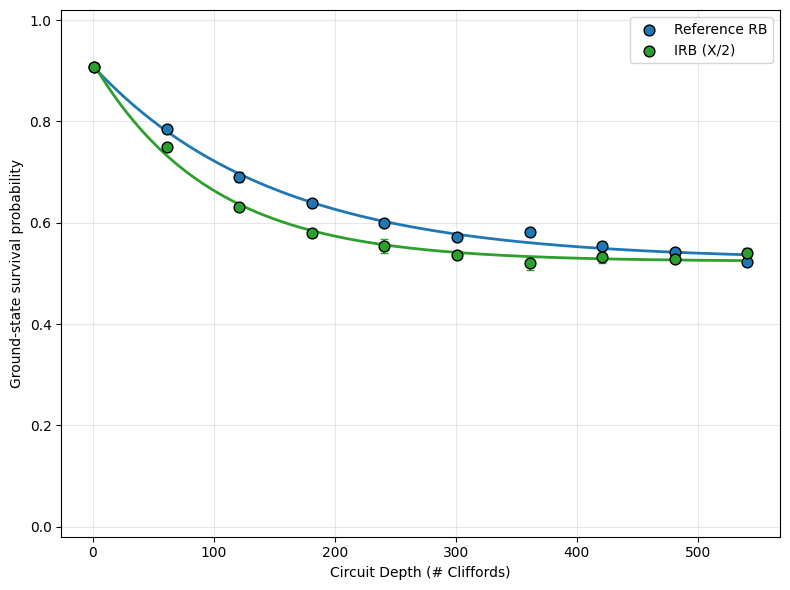

RB data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s015_RB_ref_Q1_001
RB data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s015_RB_halfX_Q1_001
AutoRB Summary
  ref         EPC=0.33467%
  X/2         F=99.8206%  EPC=0.17936%


In [48]:
from QickworkspaceV2.experiments.characterization import AutoRB

run_cfg = config_all.get_qubit(qubit)
run_cfg["pulse_type"] = "drag"
run_cfg['reps'] = 1000
# run_cfg['threshold'] = None
auto = AutoRB(run_cfg)
interleaved = ["X/2"]
auto.run(
    py_avg=1,
    max_circuit_depth=600,
    delta_clifford=60,
    number_sample=4,
    interleaved_gates=interleaved,
    # iq_process="real",
)
auto.plot()
auto.saveLabber(qubit, config_all=config_all)
print(auto.summary())

In [ ]:
from QickworkspaceV2.experiments.characterization import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

py_avg = 5
max_circuit_depth = 400
delta_clifford = 40
number_sample = 30

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
# interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
interleaved_gates_to_test = ["X/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)

# Drag


[DRAG Sum] Optimal α = 2.370358)


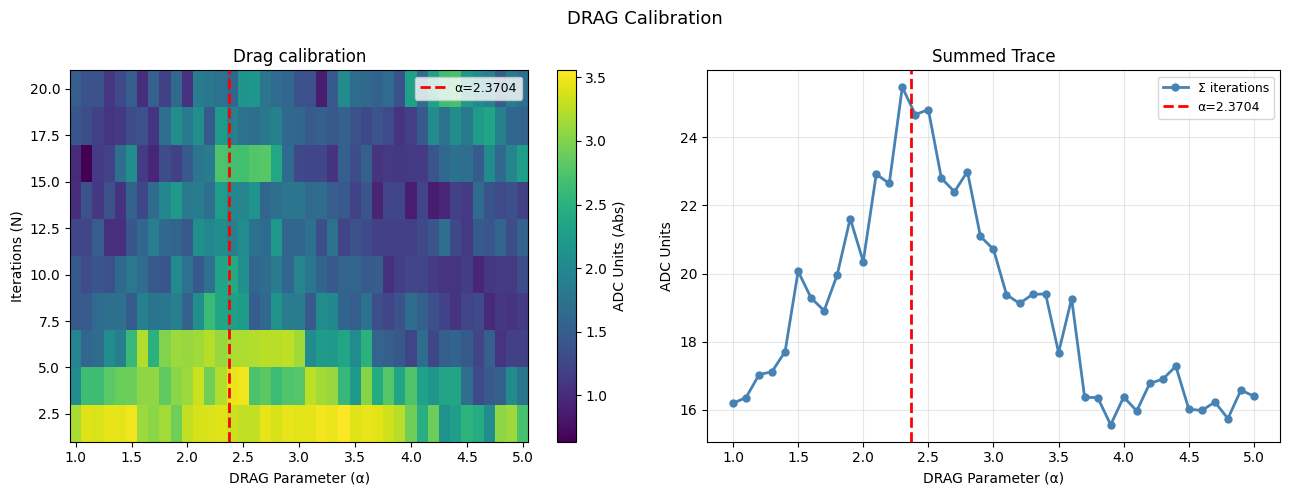

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s005a_drag_ge_Q3_20260806T084945592420Z-9JM30R04YWPGX.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0806\\s005a_drag_ge_Q3_20260806T084945592420Z-9JM30R04YWPGX.hdf5'

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import DragCalibration

run_cfg = config_all.get_qubit(qubit)
run_cfg['threshold'] = None
run_cfg.update(
    [
        # Alpha
        ("alpha_start", -2),
        ("alpha_stop", 5),
        ("alpha_steps", 41),
        # Iterations
        ("iteration_start", 2),
        ("iteration_stop", 20),
        ("iteration_step", 2),
    ]
)

drag_cal = DragCalibration(run_cfg)
fit_results = drag_cal.run(py_avg=5)

config_all.update("drag_alpha", fit_results["optimal_alpha"], q_index=qubit)
drag_cal.saveLabber(qubit, config_all=config_all)

# Active Reset Rabi A/B Test


  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

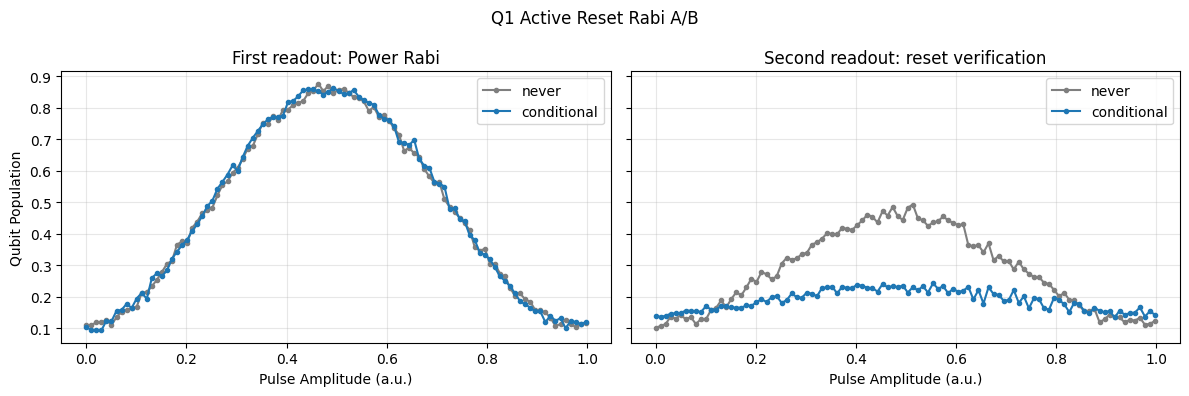

In [94]:
from qick.asm_v2 import QickSweep1D
from QickworkspaceV2.experiments.qubit_ge import ActiveResetRabi

START_GAIN = 0.0
STOP_GAIN = 1.0
STEPS = 100
PY_AVG = 1

ab_experiments = {}
ab_results = {}
for reset_mode in ("never", "conditional"):
    run_cfg = config_all.get_qubit(qubit)  # current Q1 calibration
    run_cfg.update(
        [
            ("steps", STEPS),
            ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
            ("reset_mode", reset_mode),
            ("reset_component", "I"),
            # Current Q1 rotated single-shot has I_e > I_g.
            ("reset_excited_if", ">="),
            ("read_wait", 0.2),  # resync timing validated on current Q1 [us]
            ("feedback_slack", 0.05),
            ("reset_post_delay", 0.05),
            # Intentionally short: expose the inter-shot reset benefit.
            ("relax_delay", 100.0),
            ("reps", 1000)
        ]
    )
    experiment = ActiveResetRabi(run_cfg)
    result = experiment.run(py_avg=PY_AVG, plot_analysis=False)
    ab_experiments[reset_mode] = experiment
    ab_results[reset_mode] = result

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for reset_mode, color in (("never", "tab:gray"), ("conditional", "tab:blue")):
    experiment = ab_experiments[reset_mode]
    result = ab_results[reset_mode]
    axes[0].plot(
        result.x_axis,
        np.asarray(experiment.pre_reset_population),
        "o-",
        ms=3,
        color=color,
        label=reset_mode,
    )
    axes[1].plot(
        result.x_axis,
        np.asarray(experiment.post_reset_population),
        "o-",
        ms=3,
        color=color,
        label=reset_mode,
    )

axes[0].set_title("First readout: Power Rabi")
axes[1].set_title("Second readout: reset verification")
for ax in axes:
    ax.set_xlabel("Pulse Amplitude (a.u.)")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Qubit Population")
fig.suptitle("Q1 Active Reset Rabi A/B")
fig.tight_layout()

# Active Reset Feedback Timing Test (Current Q1 Config)


Qubit                  : Q1
tProc clock            : 430.080 MHz
legacy wait_all(200)   : 0.465030 us
current relax_delay    : 300 us
threshold              : 5.687601504583682
res_phase              : 132.9471051953796 deg
pi_gain_ge             : 0.488356
timing sweep           : [0.05, 0.1, 0.2, 0.3, 0.46503, 0.5] us


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]


read_wait [us] | post mean | post peak | post span
-----------------------------------------------------
      0.050000 |    0.4766 |    0.5367 |    0.1100
      0.100000 |    0.2486 |    0.3400 |    0.2033
      0.200000 |    0.2142 |    0.3367 |    0.2233
      0.300000 |    0.2308 |    0.3167 |    0.1833
      0.465030 |    0.2269 |    0.3367 |    0.2100
      0.500000 |    0.2633 |    0.3633 |    0.1767


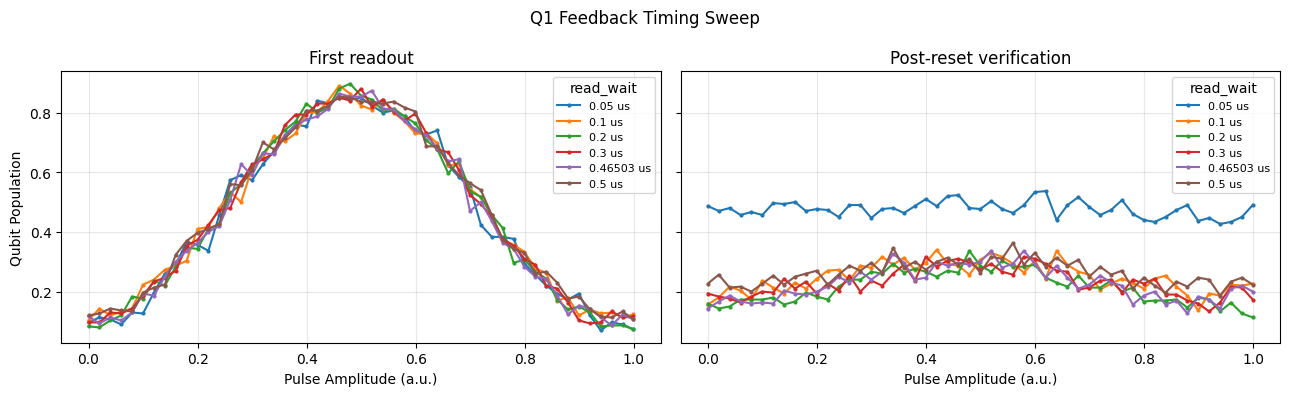

In [89]:
from qick.asm_v2 import QickSweep1D
from QickworkspaceV2.experiments.qubit_ge import ActiveResetRabi

# Use the live, currently calibrated Q1 configuration.
base_cfg = config_all.get_qubit(qubit)
f_tproc_mhz = float(soccfg["tprocs"][0]["f_time"])
legacy_wait_us = 200.0 / f_tproc_mhz
READ_WAITS_US = sorted(
    set(round(value, 6) for value in [
        0.05,
        0.10,
        0.20,
        0.3,
        legacy_wait_us,
        0.5,

    ])
)

print(f"Qubit                  : {qubit}")
print(f"tProc clock            : {f_tproc_mhz:.3f} MHz")
print(f"legacy wait_all(200)   : {legacy_wait_us:.6f} us")
print(f"current relax_delay    : {base_cfg['relax_delay']} us")
print(f"threshold              : {base_cfg['threshold']}")
print(f"res_phase              : {base_cfg['res_phase']} deg")
print(f"pi_gain_ge             : {base_cfg['pi_gain_ge']}")
print(f"timing sweep           : {READ_WAITS_US} us")

START_GAIN = 0.0
STOP_GAIN = 1.0
STEPS = 51
PY_AVG = 3

feedback_timing_runs = {}
for read_wait_us in READ_WAITS_US:
    run_cfg = config_all.get_qubit(qubit)
    run_cfg.update(
        [
            ("steps", STEPS),
            ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
            ("reset_mode", "conditional"),
            ("reset_component", "I"),
            ("reset_excited_if", ">="),
            ("read_wait", read_wait_us),
            ("feedback_slack", 0.05),
            ("reset_post_delay", 0.05),
        ]
    )
    experiment = ActiveResetRabi(run_cfg)
    result = experiment.run(py_avg=PY_AVG, plot_analysis=False)
    feedback_timing_runs[read_wait_us] = {
        "experiment": experiment,
        "result": result,
        "pre": np.asarray(experiment.pre_reset_population),
        "post": np.asarray(experiment.post_reset_population),
    }

print("\nread_wait [us] | post mean | post peak | post span")
print("-" * 53)
for read_wait_us, run in feedback_timing_runs.items():
    post = run["post"]
    print(
        f"{read_wait_us:14.6f} | {np.mean(post):9.4f} | "
        f"{np.max(post):9.4f} | {np.ptp(post):9.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for read_wait_us, run in feedback_timing_runs.items():
    x = run["result"].x_axis
    label = f"{read_wait_us:g} us"
    axes[0].plot(x, run["pre"], "o-", ms=2, label=label)
    axes[1].plot(x, run["post"], "o-", ms=2, label=label)

axes[0].set_title("First readout")
axes[1].set_title("Post-reset verification")
for ax in axes:
    ax.set_xlabel("Pulse Amplitude (a.u.)")
    ax.grid(alpha=0.3)
    ax.legend(title="read_wait", fontsize=8)
axes[0].set_ylabel("Qubit Population")
fig.suptitle(f"{qubit} Feedback Timing Sweep")
fig.tight_layout()